In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
# 1. ĐỌC DỮ LIỆU
# ==========================================
file_path = 'warmup.json'
df = pd.read_json(file_path, orient='index')

df = df.reset_index().rename(columns={'index': 'id'})

In [7]:
# 2. KIỂM TRA DỮ LIỆU KHUYẾT
# ==========================================
total_records = len(df)
missing_values = df.isnull().sum()

print("--- THỐNG KÊ TỔNG QUAN ---")
print(f"Tổng số bản ghi: {total_records}")
print("\nSố lượng giá trị bị thiếu (missing values) ở mỗi cột:")
print(missing_values)
print("-" * 30)

--- THỐNG KÊ TỔNG QUAN ---
Tổng số bản ghi: 500

Số lượng giá trị bị thiếu (missing values) ở mỗi cột:
id          0
question    0
answer      0
dtype: int64
------------------------------


In [11]:
print("\n--- 5 DÒNG MẪU ĐẦU TIÊN ---")
display(df.head())
print("-" * 30)


--- 5 DÒNG MẪU ĐẦU TIÊN ---


,id,question,answer
0,156765,Phó chủ tịch công đoàn có được quyền ký thỏa ư...,Căn cứ Điều 76 Bộ luật Lao động 2019 quy định ...
1,35781,"Trách nhiệm của tổ chức đấu thầu, bảo lãnh, đạ...","Theo Điều 37 Nghị định 153/2020/NĐ-CP, được sử..."
2,82001,Trách nhiệm của các bên liên quan trong việc t...,Căn cứ quy định tại Điều 30 Thông tư 14/2022/T...
3,37181,Người sử dụng lao động có trách nhiệm thanh to...,Căn cứ khoản 2 Điều 38 Luật An toàn vệ sinh la...
4,99969,Chứng từ kế toán phải lưu trữ vĩnh viễn đối vớ...,Chứng từ kế toán phải lưu trữ vĩnh viễn quy đị...


------------------------------


In [14]:
# 3. PHÂN TÍCH THỐNG KÊ ĐỘ DÀI VĂN BẢN
# ==========================================
# Hàm
def count_words(text):
    if pd.isna(text):
        return 0
    return len(str(text).split())
# Tạo cột
df['question_word_count'] = df['question'].apply(count_words)
df['answer_word_count'] = df['answer'].apply(count_words)

# Lấy chỉ số thống kê mô tả (min, max, mean)
stats_df = df[['question_word_count', 'answer_word_count']].agg(['min', 'max', 'mean'])

print("\n--- THỐNG KÊ MÔ TẢ ĐỘ DÀI (SỐ TỪ) ---")
print(stats_df)


--- THỐNG KÊ MÔ TẢ ĐỘ DÀI (SỐ TỪ) ---
      question_word_count  answer_word_count
min                 5.000             37.000
max                43.000           1829.000
mean               19.146            343.182


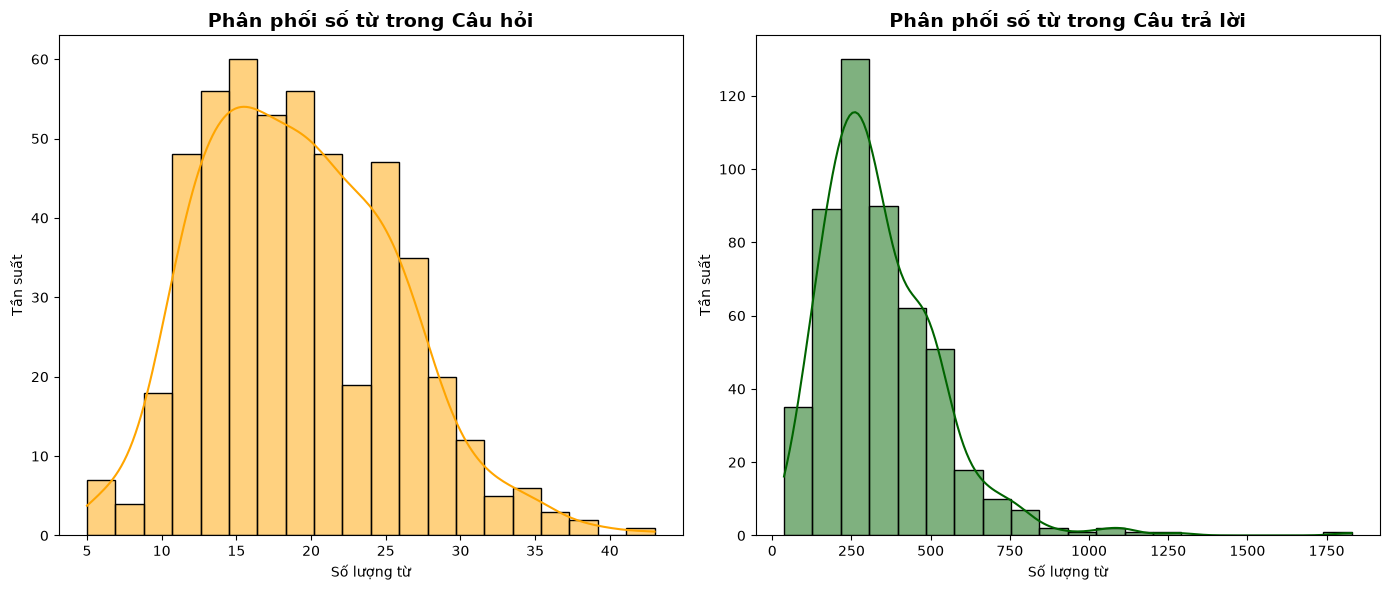

In [16]:
# 5. TRỰC QUAN HÓA
# ==========================================
plt.figure(figsize=(14, 6))

# Biểu đồ phân phối số từ của Câu hỏi (Màu zàng)
plt.subplot(1, 2, 1)
sns.histplot(df['question_word_count'], bins=20, color='#FFA500', kde=True)
plt.title('Phân phối số từ trong Câu hỏi', fontsize=14, fontweight='bold')
plt.xlabel('Số lượng từ')
plt.ylabel('Tần suất')

# Biểu đồ phân phối số từ của Câu trả lời (Màu Deep Green)
plt.subplot(1, 2, 2)
sns.histplot(df['answer_word_count'], bins=20, color='#006400', kde=True)
plt.title('Phân phối số từ trong Câu trả lời', fontsize=14, fontweight='bold')
plt.xlabel('Số lượng từ')
plt.ylabel('Tần suất')

plt.tight_layout()
plt.show()